In [41]:
import numpy as np
import pandas as pd
import torch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification


In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/gscdit/Breast-Cancer-Detection/refs/heads/master/data.csv')
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [3]:
df.shape

(569, 33)

# Drop columns

In [4]:
df.drop(columns=['Unnamed: 32', 'id'], inplace=True)

In [5]:
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


# Train test split


In [6]:
X_train, X_test, y_train, y_test = train_test_split(df.iloc[:,1:],df.iloc[:,0],test_size=.2,random_state=42)


In [9]:
df['diagnosis'].unique()

array(['M', 'B'], dtype=object)

# Scaling

In [7]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Encoder


In [8]:
labelencoder = LabelEncoder()
y_train = labelencoder.fit_transform(y_train)
y_test = labelencoder.transform(y_test)

In [10]:
X_train

array([[-1.44075296, -0.43531947, -1.36208497, ...,  0.9320124 ,
         2.09724217,  1.88645014],
       [ 1.97409619,  1.73302577,  2.09167167, ...,  2.6989469 ,
         1.89116053,  2.49783848],
       [-1.39998202, -1.24962228, -1.34520926, ..., -0.97023893,
         0.59760192,  0.0578942 ],
       ...,
       [ 0.04880192, -0.55500086, -0.06512547, ..., -1.23903365,
        -0.70863864, -1.27145475],
       [-0.03896885,  0.10207345, -0.03137406, ...,  1.05001236,
         0.43432185,  1.21336207],
       [-0.54860557,  0.31327591, -0.60350155, ..., -0.61102866,
        -0.3345212 , -0.84628745]])

In [11]:
y_train

array([0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1,
       0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0,
       1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0,
       0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1,
       0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0,
       1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1,
       1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0,

# Numpy Array to tensors

In [48]:
#numpy to tensor
X_train_tensor = torch.from_numpy(X_train)
X_test_tensor = torch.from_numpy(X_test)

#change dtype
X_train_tensor = torch.tensor(X_train_tensor, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_tensor, dtype=torch.float32)

#numpy to tensor
y_train_tensor = torch.from_numpy(y_train)
y_test_tensor = torch.from_numpy(y_test)

y_train_tensor = torch.tensor(y_train_tensor,dtype= torch.float32)
y_test_tensor = torch.tensor(y_test_tensor, dtype=torch.float32)

# y_test_tensor = torch.from_numpy(y_test)

/tmp/ipykernel_859/3826779354.py:6: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_train_tensor = torch.tensor(X_train_tensor, dtype=torch.float32)
/tmp/ipykernel_859/3826779354.py:7: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_test_tensor = torch.tensor(X_test_tensor, dtype=torch.float32)
/tmp/ipykernel_859/3826779354.py:13: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_train_tensor = torch.tensor(y_train_tensor,dtype= torch.float32)
/tmp/ipykernel_859/3826779354.py:14: UserWarning: To copy construct from a tensor, it is recommend

In [14]:
import torch.nn as nn

# Dataset and Dataloader

In [49]:
from torch.utils.data import Dataset, DataLoader, TensorDataset
class CustomDataset(Dataset):
  def __init__(self,features,labels):
    self.features = features
    self.labels = labels

  def __len__(self):
    return self.features.shape[0]

  def __getitem__(self,index):
    return self.features[index], self.labels[index]

In [50]:
train_dataset = CustomDataset(X_train_tensor, y_train_tensor)
test_dataset = CustomDataset(X_test_tensor, y_test_tensor)
#

In [51]:
len(train_dataset)

455

In [52]:
train_dataset[2]

(tensor([-1.4000, -1.2496, -1.3452, -1.1098, -1.3326, -0.3074, -0.3656, -0.6965,
          1.9303,  0.9544,  0.0275,  1.9631, -0.1210, -0.3508,  0.5728,  0.7395,
          0.3207,  0.5895,  2.6150,  0.7189, -1.2953, -1.0408, -1.2452, -0.9997,
         -1.4387, -0.5486, -0.6449, -0.9702,  0.5976,  0.0579]),
 tensor(0.))

In [53]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=True)

In [12]:
X_train.shape[1]

30

In [54]:
class SimpleNN(nn.Module):
  def __init__(self,num_features):
    super().__init__()

    self.linear = nn.Linear(num_features,1)

    self.sigmoid= nn.Sigmoid()

  def forward(self,features):
    out = self.linear(features)
    out = self.sigmoid(out)

    return out

In [55]:
X_train_tensor.shape[1]

30

In [56]:
#parameters
learning_rate = 0.1
num_epochs = 35

In [57]:
loss_function =nn.BCELoss()

In [58]:
type(loss_function)

torch.nn.modules.loss.BCELoss

In [21]:
model = SimpleNN(X_train_tensor.shape[1])
model.parameters()

<generator object Module.parameters at 0x7c2d1a9d0ac0>

In [31]:
for param in model.parameters():
    print(type(param), param.size())

<class 'torch.nn.parameter.Parameter'> torch.Size([1, 30])
<class 'torch.nn.parameter.Parameter'> torch.Size([1])


# Pipeline

Epoch 5, Avg Loss =0.1185
Epoch 10, Avg Loss =0.1058
Epoch 15, Avg Loss =0.0820
Epoch 20, Avg Loss =0.0759
Epoch 25, Avg Loss =0.0742
Epoch 30, Avg Loss =0.0739
Epoch 35, Avg Loss =0.0672


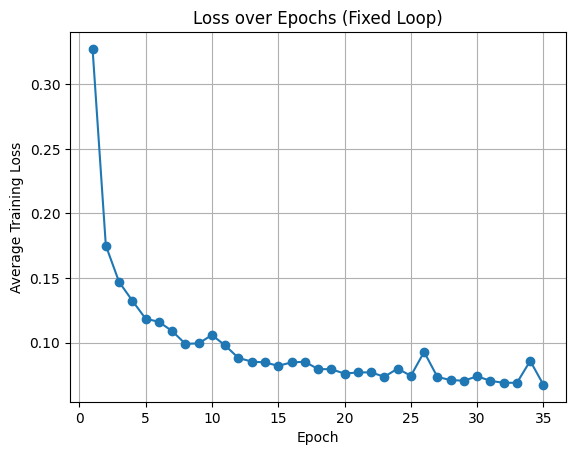

In [61]:
#Create model
model = SimpleNN(X_train_tensor.shape[1])

#losses
losses = []

#Optimizer
optimizer = torch.optim.SGD(model.parameters(), lr = learning_rate)

for epoch in range(num_epochs):
  epoch_loss = 0
  #forward pass
  for batch_features, batch_labels in train_loader:
    y_pred = model(batch_features)

    # Loss calculate (Inside the loop now)
    loss = loss_function(y_pred, batch_labels.reshape(-1,1))

    # Zero grad
    optimizer.zero_grad()

    # backward pass
    loss.backward()

    # Parameter update
    optimizer.step()

    epoch_loss += loss.item()

  avg_loss = epoch_loss / len(train_loader)
  losses.append(avg_loss)

  if (epoch + 1) % 5 == 0:
    print(f"Epoch {epoch+1}, Avg Loss ={avg_loss:.4f}")

plt.plot(range(1, num_epochs+1), losses, marker='o')
plt.xlabel('Epoch')
plt.ylabel('Average Training Loss')
plt.title('Loss over Epochs (Fixed Loop)')
plt.grid(True)
plt.show()

# Training pipeline version 2

 Start index 0, end indx 32

 Start index 32, end indx 64

 Start index 64, end indx 96

 Start index 96, end indx 128

 Start index 128, end indx 160

 Start index 160, end indx 192

 Start index 192, end indx 224

 Start index 224, end indx 256

 Start index 256, end indx 288

 Start index 288, end indx 320

 Start index 320, end indx 352

 Start index 352, end indx 384

 Start index 384, end indx 416

 Start index 416, end indx 448

 Start index 448, end indx 480

 1 , Loss = 0.19663961231708527 
 Start index 0, end indx 32

 Start index 32, end indx 64

 Start index 64, end indx 96

 Start index 96, end indx 128

 Start index 128, end indx 160

 Start index 160, end indx 192

 Start index 192, end indx 224

 Start index 224, end indx 256

 Start index 256, end indx 288

 Start index 288, end indx 320

 Start index 320, end indx 352

 Start index 352, end indx 384

 Start index 384, end indx 416

 Start index 416, end indx 448

 Start index 448, end indx 480

 2 , Loss = 0.138342902

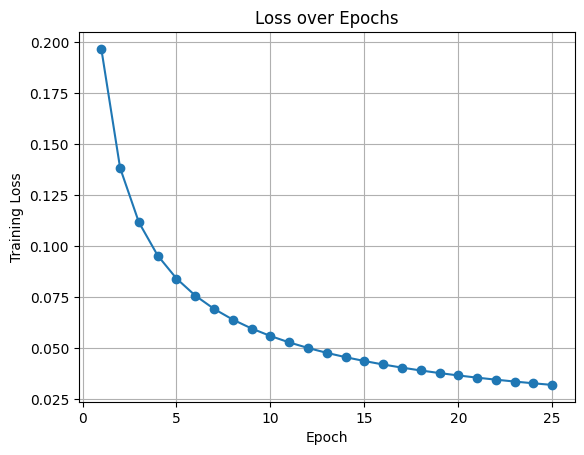

In [33]:
#create model

model = SimpleNN(X_train_tensor.shape[1])

#optimizer
optimizer = torch.optim.SGD( model.parameters(), lr = learning_rate )

#define loop
batch_size = 32
num_epochs = 25
n_sample = len(X_train_tensor)

#losses (re-initialize for this training run)
losses = []

for epoch in range(num_epochs):

  for start_indx in range(0,n_sample,batch_size):
    end_indx = start_indx + batch_size

    print(f" Start index {start_indx}, end indx {end_indx}\n")

    X_batch = X_train_tensor[start_indx:end_indx]
    y_batch = y_train_tensor[start_indx:end_indx]

    #forward pass
    y_pred = model(X_batch)
    loss = loss_function(y_pred,y_batch.reshape(-1,1))


    #upate step

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

  losses.append(loss.item())

  #print loss in each epoch

  print(f" {epoch+1} , Loss = {loss.item()} ")


plt.plot(range(1, num_epochs+1), losses, marker='o')
plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.title('Loss over Epochs')
plt.grid(True)
plt.show()

# Model Evaluation (old)

Accuracy: 0.5430901646614075



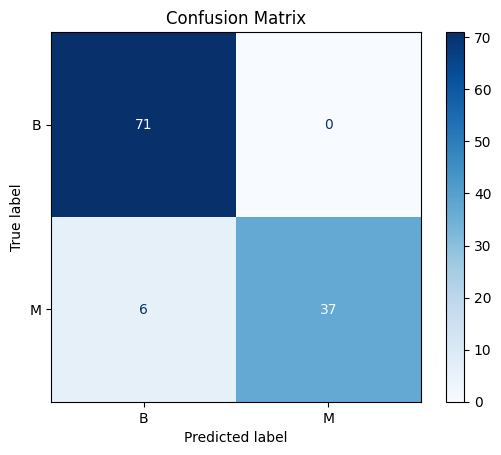

In [62]:

with torch.no_grad():
  y_pred = model.forward(batch)
  y_pred = (y_pred > 0.9).float()

  accuracy = (y_pred == y_test_tensor).float().mean()
  print(f"Accuracy: {accuracy}\n")

cm = confusion_matrix(y_test_tensor, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=labelencoder.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

# Better version

In [70]:
y_pred.shape

torch.Size([18, 1])

In [71]:
batch_labels.shape

torch.Size([18])

In [78]:
model.eval()

accuracy_list = []

with torch.no_grad():
  for batch_features, batch_labels in test_loader:
    y_pred = model(batch_features)
    y_pred = (y_pred > 0.5).float()

    batch_accuracy = (y_pred.view(-1) == batch_labels).float().mean().item()

    accuracy_list.append(batch_accuracy)

overall_accuracy = sum(accuracy_list) / len(accuracy_list)
print(f"Overall Accuracy: {overall_accuracy}")
    # print(y_pred)

Overall Accuracy: 0.9782986044883728


In [74]:
accuracy_list

[0.96875, 1.0, 1.0, 0.9444444179534912]

In [36]:
y_pred.shape

torch.Size([18, 1])

In [37]:
batch_labels.shape

torch.Size([18, 1])

In [39]:
model.eval()  # evaluation mode
accuracy_list = []

with torch.no_grad():
  for batch_features, batch_labels in test_loader:
    y_pred = model(batch_features)
    y_pred = (y_pred > 0.5).float()

    # Ensure shapes match to avoid broadcasting errors
    batch_accuracy = (y_pred.view_as(batch_labels) == batch_labels).float().mean().item()

    accuracy_list.append(batch_accuracy)

overall_accuracy = sum(accuracy_list) / len(accuracy_list)
print(f"Overall Accuracy: {overall_accuracy}")

Overall Accuracy: 0.9704861044883728


# Summary

In [ ]:
from torchinfo import summary


summary(model, input_size=(455,30))

### Investigating the Shape Mismatch
The labels `y_train` and `y_test` start as 1D numpy arrays. When they are converted to tensors, you added `.unsqueeze(1)`, changing their shape from `(N,)` to `(N, 1)`.

In your 'Better version', `test_loader` yields batches where `batch_labels` also has the shape `(batch, 1)`. However, the model output `y_pred` also has shape `(batch, 1)`. Previously, you used `y_pred.view(-1)`, which turned a `(32, 1)` tensor into a `(32,)` tensor. Comparing a `(32,)` tensor with a `(32, 1)` tensor triggers **broadcasting**, creating a `(32, 32)` matrix, which makes the accuracy calculation incorrect.

In [40]:
# Let's verify the current shapes of the tensors
print(f"y_test_tensor shape: {y_test_tensor.shape}")

# Simulating the mismatch that happened before the fix:
# y_pred (flattened) vs batch_labels (2D)
test_batch_features, test_batch_labels = next(iter(test_loader))
test_y_pred = model(test_batch_features)
test_y_pred_flat = (test_y_pred > 0.5).float().view(-1)

print(f"Shape of flattened y_pred: {test_y_pred_flat.shape}")
print(f"Shape of batch_labels: {test_batch_labels.shape}")
print(f"Broadcasted result shape (The Culprit): {(test_y_pred_flat == test_batch_labels).shape}")

y_test_tensor shape: torch.Size([114, 1])
Shape of flattened y_pred: torch.Size([32])
Shape of batch_labels: torch.Size([32, 1])
Broadcasted result shape (The Culprit): torch.Size([32, 32])
